In [44]:
import sqlite3
from typing import Callable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 0
Data extraction: get the data from 3 tables & combine it into single `.csv` file.
After that read this file using pandas to create Dataframe.
So it will be all joined data in 1 dataframe. Quick check - should be 74818 rows in it.

In [23]:
conn = sqlite3.connect("../db.sqlite3")

query = """
SELECT *
FROM restaurant_orderitem oi
JOIN restaurant_order o ON oi.order_id = o.id
JOIN restaurant_product p ON oi.product_id = p.id
"""

df = pd.read_sql_query(query, conn)
df.to_csv("restaurant_analysis.csv", index=False, encoding="utf-8")

# Task 1
Get Top 10 most popular products in restaurant sold by Quantity.
Count how many times each product was sold and create a pie chart with percentage of popularity (by quantity) for top 10 of them.

Example:

![pie chart](../demo/pie.png)

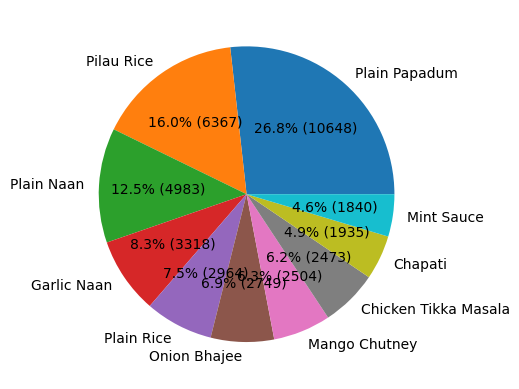

In [45]:
top10 = df.groupby("name")["quantity"].sum().sort_values(ascending=False).head(10)

labels = top10.index
values = top10.values


def make_auto_pct(nums: list[int] | np.ndarray) -> Callable:
    def my_auto_pct(pct: float) -> str:
        total = sum(nums)
        count = int(round(pct * total / 100))
        return f"{pct:.1f}% ({count})"

    return my_auto_pct


plt.pie(values, labels=labels, autopct=make_auto_pct(values))
plt.show()

# Task 2
Calculate `Item Price` (Product Price * Quantity) for each Order Item in dataframe.
And Make the same Top 10 pie chart, but this time by `Item Price`. So this chart should describe not the most popular products by quantity, but which products (top 10) make the most money for restaurant. It should be also with percentage.

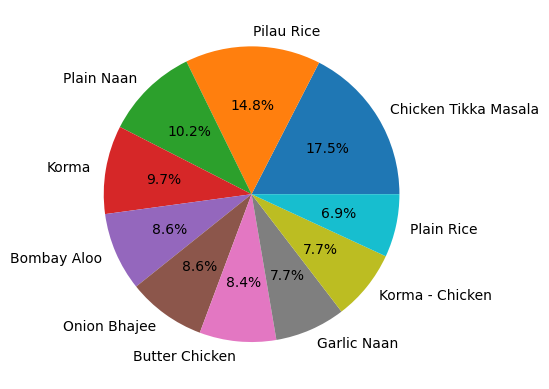

In [53]:
df["item_price"] = df["price"] * df["quantity"]
top10_price = df.groupby("name")["item_price"].sum().sort_values(ascending=False).head(10)

labels = top10_price.index
values = top10_price.values

plt.pie(values, labels=labels, autopct="%1.1f%%")
plt

# Task 3
Calculate `Order Hour` based on `Order Datetime`, which will tell about the specific our the order was created (from 0 to 23). Using `Order Hour` create a bar chart, which will tell the total restaurant income based on the hour order was created. So on x-axis - it will be values from 0 to 23 (hours), on y-axis - it will be the total sum of order prices, which were sold on that hour.

Example:

![bar chart](../demo/bar.png)

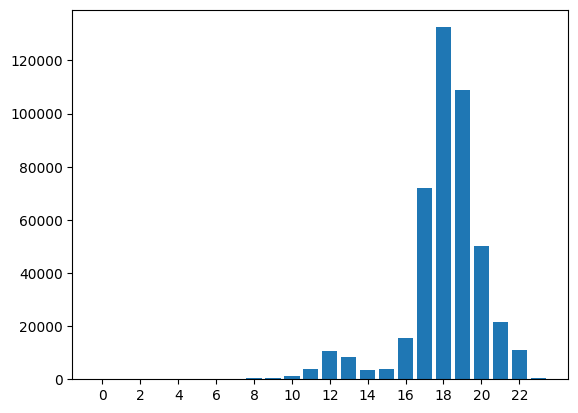

In [77]:
df["datetime"] = pd.to_datetime(df["datetime"])
df["order_hour"] = df["datetime"].dt.hour
total_income_by_hour = df.groupby("order_hour")["item_price"].sum()
total_income_by_hour = total_income_by_hour.reindex(range(24), fill_value=0)

plt.bar(total_income_by_hour.index, total_income_by_hour.values)
plt.xticks(range(0, 24, 2))
plt.show()

# Task 4
Make similar bar chart, but right now with `Order Day Of The Week` (from Monday to Sunday), and also analyze total restaurant income by each day of the week.

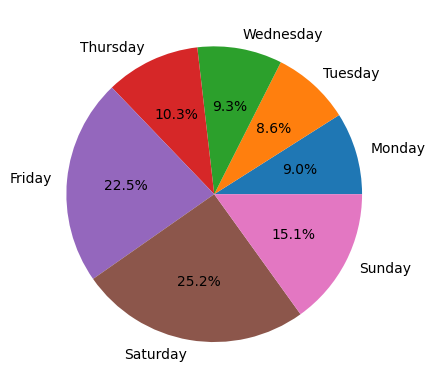

In [95]:
df["day_of_week"] = df["datetime"].dt.day_name()
day_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["day_of_week"] = pd.Categorical(
    df["day_of_week"],
    categories=day_of_week,
    ordered=True
)
total_income_by_day = df.groupby("day_of_week")["item_price"].sum()

plt.pie(total_income_by_day.values, labels=day_of_week, autopct="%1.1f%%")
plt.show()